In [ ]:
conda install torchvision opencv-python pillow matplotlib insightface

In [ ]:
pip install insightface

In [ ]:
pip install insightface onnxruntime-silicon opencv-python -q

In [ ]:
conda install onnxruntime -c conda-forge

In [ ]:
conda install protobuf

# Loss function preparing

### L1 loss (pixel loss)

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

Device: mps


In [3]:
import torch
import torch.nn as nn

# L1 loss (reconstruction loss)
# Mean absolute pixel difference between SR output and HR ground truth.
l1_criterion = nn.L1Loss(reduction='mean')  # standard choice

### VGG 19 Perceptual loss

In [5]:
import torch
import torch.nn as nn
from torchvision.models import vgg19, VGG19_Weights


class VGGPerceptualLoss(nn.Module):
    def __init__(self, layer_name='relu4_1', use_l1=True):
        super().__init__()

        # Load pretrained VGG19
        vgg = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features

        # Map human-readable names to index in vgg.features
        # VGG19: conv/relu layers order; we pick until relu4_1 (~layer 21)
        layer_map = {
            'relu1_1': 1,
            'relu1_2': 3,
            'relu2_1': 6,
            'relu2_2': 8,
            'relu3_1': 11,
            'relu3_2': 13,
            'relu3_3': 15,
            'relu3_4': 17,
            'relu4_1': 20,
            'relu4_2': 22,
            'relu4_3': 24,
            'relu4_4': 26,
        }
        assert layer_name in layer_map, f"Unknown layer_name: {layer_name}"
        cutoff = layer_map[layer_name]

        # Keep VGG up to the chosen layer
        self.vgg = nn.Sequential(*[vgg[i] for i in range(cutoff + 1)])
        for p in self.vgg.parameters():
            p.requires_grad = False  # freeze

        # ImageNet normalization parameters
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

        # Distance in feature space
        self.criterion = nn.L1Loss() if use_l1 else nn.MSELoss()

    def normalize(self, x):
        # Input x is assumed to be in [0, 1]
        return (x - self.mean) / self.std

    def forward(self, sr, hr):
        """
        sr, hr: (N,3,H,W) in [0,1]
        """
        sr_norm = self.normalize(sr)
        hr_norm = self.normalize(hr)

        with torch.no_grad():
            feat_hr = self.vgg(hr_norm)
        # Allow gradients only through SR side
        feat_sr = self.vgg(sr_norm)

        loss = self.criterion(feat_sr, feat_hr)
        return loss


In [6]:
vgg_loss_fn = VGGPerceptualLoss(layer_name='relu4_1', use_l1=True).to(device)
print(device)

mps


### ArcFace Loss

In [7]:
import onnxruntime
print("module:", onnxruntime)
print("file:", getattr(onnxruntime, "__file__", "no __file__"))
print("has InferenceSession:", "InferenceSession" in dir(onnxruntime))

module: <module 'onnxruntime' from '/opt/miniconda3/envs/swin/lib/python3.10/site-packages/onnxruntime/__init__.py'>
file: /opt/miniconda3/envs/swin/lib/python3.10/site-packages/onnxruntime/__init__.py
has InferenceSession: True


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2

from insightface.app import FaceAnalysis

In [9]:
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0 if torch.cuda.is_available() else -1, det_size=(256, 256))

/opt/miniconda3/envs/swin/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:121: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/abdi/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/abdi/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/abdi/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/abdi/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/abdi/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det

In [10]:
class InsightFaceBackbone(nn.Module):
    def __init__(self, app):
        super().__init__()
        # app is the FaceAnalysis instance
        self.app = app

    def forward(self, x):
        """
        x: (N,3,H,W) torch tensor in [0,1], RGB
        returns: (N, D) torch tensor of embeddings
        """
        x_np = x.detach().cpu().numpy()
        embs = []

        for img in x_np:
            # CHW -> HWC
            img = np.transpose(img, (1, 2, 0))  # (H,W,3), float32 [0,1]
            # [0,1] -> [0,255], uint8
            img = (img * 255).astype(np.uint8)
            # InsightFace expects BGR
            img_bgr = img[:, :, ::-1]

            faces = self.app.get(img_bgr)  # list of faces
            if len(faces) == 0:
                # if no face is found, just use zeros (or skip, up to you)
                # embedding size is typically 512
                emb = np.zeros((512,), dtype=np.float32)
            else:
                emb = faces[0].embedding.astype(np.float32)  # (D,)
            embs.append(emb)

        embs = np.stack(embs, axis=0)  # (N,D)
        embs = torch.from_numpy(embs).float().to(x.device)
        return embs

In [11]:
arcface_backbone = InsightFaceBackbone(app).to(device)
arcface_backbone.eval()

InsightFaceBackbone()

In [12]:
class ArcFaceIdentityLoss(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone.eval()
        for p in self.backbone.parameters():
            p.requires_grad = False  # we never train ArcFace

    def forward(self, sr, hr):
        """
        sr, hr: (N,3,H,W) in [0,1]
        """
        with torch.no_grad():
            emb_hr = self.backbone(hr)  # (N,D)

        emb_sr = self.backbone(sr)      # (N,D), gradients flow via sr

        emb_hr = F.normalize(emb_hr, p=2, dim=1)
        emb_sr = F.normalize(emb_sr, p=2, dim=1)

        cos_sim = (emb_sr * emb_hr).sum(dim=1)  # (N,)
        loss = 1.0 - cos_sim.mean()
        return loss


In [13]:
id_loss_fn = ArcFaceIdentityLoss(arcface_backbone).to(device)

# Loss function Testing

HR shape: torch.Size([1, 3, 144, 108])
LR (resized) shape: torch.Size([1, 3, 144, 108])


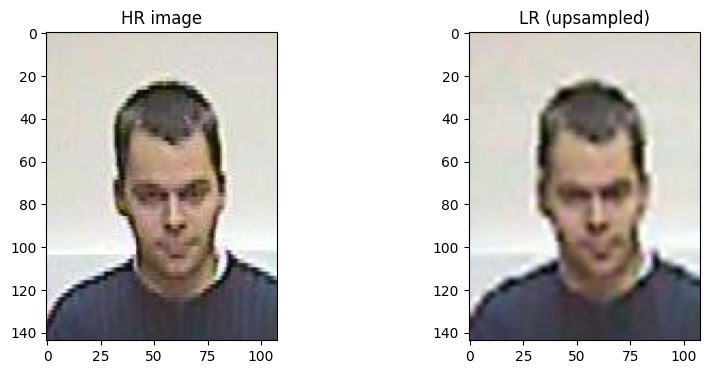

In [14]:
# Test that the losses are working prop

from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt


# Paths
hr_path = "SWINIR_dataset/train/HR/010_cam2_2.jpg"
lr_path = "SWINIR_dataset/train/LR/010_cam2_2.jpg"

# Load images
hr_img = Image.open(hr_path).convert("RGB")
lr_img = Image.open(lr_path).convert("RGB")

# Upsample LR to HR size so we can compare directly (only for testing L1!)
lr_img_resized = lr_img.resize(hr_img.size, Image.BICUBIC)

# Convert to tensors in [0,1]
to_tensor = transforms.ToTensor()
hr_tensor = to_tensor(hr_img).unsqueeze(0)   # (1,3,H,W)
lr_tensor = to_tensor(lr_img_resized).unsqueeze(0)

lr_tensor = lr_tensor.to(device)
hr_tensor = hr_tensor.to(device)

print("HR shape:", hr_tensor.shape)
print("LR (resized) shape:", lr_tensor.shape)


plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(hr_img); plt.title("HR image")
plt.subplot(1,2,2); plt.imshow(lr_img_resized); plt.title("LR (upsampled)")
plt.show()


### L1 LOSS (pixel reconstruction loss)

- Definition:
    L1 = mean( |SR - HR| )

- Output range:
    0 to 2 (for normalized images in [0,1], realistic values ~0 to 0.2)

- Expected behavior:
    • Same images (SR == HR):
        L1 ≈ 0.0 – 0.02
        (small but not always exactly zero due to minor preprocessing differences)
    • Different images:
        Higher values, typically 0.05 – 0.5

- Interpretation:
    Measures raw pixel error.
    Lower = better. Does NOT know anything about shapes or identity.

In [15]:
# l1 loss test, we should see
l1 = nn.L1Loss(reduction='mean')
loss_value = l1_criterion(lr_tensor, hr_tensor)
print("L1 loss:", loss_value.item())

L1 loss: 0.03158881887793541


### VGG PERCEPTUAL LOSS

- Definition:
    L_perc = L1( VGG_features(SR), VGG_features(HR) )

- Output range:
    No strict upper bound, but typical:
    ~0.0 (identical) to ~5.0 (completely different)
    For face images, usually 0.0 – 2.0.

- Expected behavior:
    • Same images:
        ~0.0 – 0.1 for raw tensors
        BUT if LR and HR differ even slightly, VGG loss jumps significantly.
        For LR vs HR, values like 0.5 – 2.0 are NORMAL.
    • Different images:
        Higher values, 1.0 – 4.0 depending on content.

- Interpretation:
    Measures deep feature differences (edges, shapes, textures).
    Much more sensitive than pixel L1.
    Large even for small visual differences.



In [16]:
loss_vgg = vgg_loss_fn(lr_tensor, hr_tensor)
print("Perceptual loss (same images):", loss_vgg.item())

Perceptual loss (same images): 0.9743878245353699


### ARCFACE IDENTITY LOSS (identity-preserving embedding loss)

- Definition:
    L_id = 1 - cosine_similarity( emb(SR), emb(HR) )

- Output range:
    0 to 2 (cosine similarity ∈ [-1, 1])
    Practical range for real face images: 0.0 – 1.0

- Expected behavior:
    • Same image:
        L_id ≈ 0.0 – 0.1
        (Rarely exactly 0 due to resizing, color conversion, alignment, ArcFace noise)
    • Slightly different images (e.g., SR noisy):
        L_id ≈ 0.1 – 0.4
    • Completely different faces:
        L_id ≈ 0.7 – 1.0

- Interpretation:
    Measures identity mismatch in ArcFace embedding space.
    Lower = better identity preservation.
    Most important metric for face SR aimed at recognition.


In [17]:
loss_id = id_loss_fn(lr_tensor, hr_tensor)
print("Identity loss (same images):", loss_id.item())

Identity loss (same images): 0.2581334710121155


/opt/miniconda3/envs/swin/lib/python3.10/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


## SWIN IR Super Resolution training

In [18]:
!git clone https://github.com/JingyunLiang/SwinIR.git

fatal: destination path 'SwinIR' already exists and is not an empty directory.


In [19]:
import sys
sys.path.append("SwinIR")

from models.network_swinir import SwinIR

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from pathlib import Path
from PIL import Image
import torchvision.transforms as T
import random

/opt/miniconda3/envs/swin/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [24]:
class PairedRestorationDataset(Dataset):
    def __init__(self, root, split="train", size=128):
        """
        root: dataset_root (contains train/val/test with LR/HR subfolders)
        split: 'train' / 'val' / 'test'
        size: target H=W for both LR and HR (e.g. 128 or 256)
        """
        self.root = Path(root)
        self.split = split
        self.size = size

        split_dir = self.root / split
        self.lr_dir = split_dir / "LR"
        self.hr_dir = split_dir / "HR"

        hr_paths = sorted(list(self.hr_dir.glob("*")))
        lr_paths = sorted(list(self.lr_dir.glob("*")))
        assert len(hr_paths) == len(lr_paths), f"LR/HR count mismatch in {split}"

        lr_map = {p.stem: p for p in lr_paths}
        self.pairs = []
        for hr_p in hr_paths:
            key = hr_p.stem
            if key in lr_map:
                self.pairs.append((lr_map[key], hr_p))
        assert len(self.pairs) > 0, f"No LR/HR pairs found in {split}"

        self.transform = T.Compose([
            T.Resize((size, size), interpolation=Image.BICUBIC),
            T.ToTensor(),   # -> [0,1]
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        lr_path, hr_path = self.pairs[idx]
        lr_img = Image.open(lr_path).convert("RGB")
        hr_img = Image.open(hr_path).convert("RGB")

        lr_t = self.transform(lr_img)  # (3,size,size)
        hr_t = self.transform(hr_img)  # (3,size,size)

        return lr_t, hr_t


train_dataset = PairedRestorationDataset(data_root, split="train", size=train_size)
val_dataset   = PairedRestorationDataset(data_root, split="val",   size=train_size)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,      # important on macOS / MPS
    pin_memory=False,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Train samples: 1980, Val samples: 440


## Data Loaders

In [25]:


train_dataset = PairedRestorationDataset(data_root, split="train", size=train_size)
val_dataset   = PairedRestorationDataset(data_root, split="val",   size=train_size)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,         
    pin_memory=False,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
)

In [27]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = SwinIR(
    upscale=1,              # for same-size restoration
    in_chans=3,
    img_size=train_size,
    window_size=8,
    img_range=1.0,
    depths=[6, 6, 6, 6],
    embed_dim=60,
    num_heads=[6, 6, 6, 6],
    mlp_ratio=2.0,
    upsampler=None,         # restoration mode, no pixelshuffle
).to(device)

# Full Training

In [31]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm.auto import tqdm, trange


# SwinIR
import sys
sys.path.append("SwinIR")
from models.network_swinir import SwinIR

# --- Basic config ---
data_root   = "Documents/Deep Learning/dataset_256_ready 2"  # your dataset root
train_size  = 128      # resize H=W for training (128 or 256)
batch_size  = 1
num_epochs  = 20       # you can increase later
learning_rate = 1e-4

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

torch.set_num_threads(4)  # optional, can help a bit on CPU parts


Using device: mps


In [28]:
# --- SwinIR model (restoration, no upscaling) ---
model = SwinIR(
    upscale=1,              # SAME size in/out
    in_chans=3,
    img_size=train_size,    # 128 or 256
    window_size=8,
    img_range=1.0,          # input in [0,1]
    depths=[6, 6, 6, 6],
    embed_dim=60,
    num_heads=[6, 6, 6, 6],
    mlp_ratio=2.0,
    upsampler=None,         # IMPORTANT: no pixelshuffle
).to(device)

# --- Losses ---
l1_criterion = nn.L1Loss(reduction='mean')

# VGG perceptual (you already defined VGGPerceptualLoss)
vgg_loss_fn = VGGPerceptualLoss(layer_name='relu4_1', use_l1=True).to(device)

# ArcFace identity (you already have app, InsightFaceBackbone, ArcFaceIdentityLoss)
arcface_backbone = InsightFaceBackbone(app).to(device)
id_loss_fn       = ArcFaceIdentityLoss(arcface_backbone).to(device)

lambda_perc = 0.1
lambda_id   = 0.5

# --- Optimizer & scheduler ---
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    betas=(0.9, 0.99),
    weight_decay=1e-4,
)

# Simple scheduler: decay LR by 0.5 at epochs 10 and 15
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[10, 15],
    gamma=0.5,
)

In [29]:
# ====== TRAIN / VAL STEP FUNCTIONS WITH TQDM ======
def train_one_epoch(model, optimizer, train_loader, device):
    model.train()
    running = {"total": 0.0, "l1": 0.0, "vgg": 0.0, "id": 0.0}
    n_samples = 0

    pbar = tqdm(train_loader, desc="Training")


    for lr_batch, hr_batch in pbar:
        lr_batch = lr_batch.to(device)
        hr_batch = hr_batch.to(device)
        bsz = lr_batch.size(0)
        n_samples += bsz

        optimizer.zero_grad()

        sr_batch = model(lr_batch)

        loss_l1  = l1_criterion(sr_batch, hr_batch)
        loss_vgg = vgg_loss_fn(sr_batch, hr_batch)
        loss_id  = id_loss_fn(sr_batch, hr_batch)

        loss_total = loss_l1 + lambda_perc * loss_vgg + lambda_id * loss_id
        loss_total.backward()
        optimizer.step()

        running["total"] += loss_total.item() * bsz
        running["l1"]    += loss_l1.item()      * bsz
        running["vgg"]   += loss_vgg.item()     * bsz
        running["id"]    += loss_id.item()      * bsz

        pbar.set_postfix({
            "total": f"{loss_total.item():.3f}",
            "L1":    f"{loss_l1.item():.3f}",
            "VGG":   f"{loss_vgg.item():.3f}",
            "ID":    f"{loss_id.item():.3f}",
        })

    avg = {k: v / n_samples for k, v in running.items()}
    return avg


@torch.no_grad()
def validate(model, val_loader, device):
    model.eval()
    running = {"total": 0.0, "l1": 0.0, "vgg": 0.0, "id": 0.0}
    n_samples = 0

    pbar = tqdm(val_loader, desc="Validation")

    for lr_batch, hr_batch in pbar:
        lr_batch = lr_batch.to(device)
        hr_batch = hr_batch.to(device)
        bsz = lr_batch.size(0)
        n_samples += bsz

        sr_batch = model(lr_batch)

        loss_l1  = l1_criterion(sr_batch, hr_batch)
        loss_vgg = vgg_loss_fn(sr_batch, hr_batch)
        loss_id  = id_loss_fn(sr_batch, hr_batch)

        loss_total = loss_l1 + lambda_perc * loss_vgg + lambda_id * loss_id

        running["total"] += loss_total.item() * bsz
        running["l1"]    += loss_l1.item()      * bsz
        running["vgg"]   += loss_vgg.item()     * bsz
        running["id"]    += loss_id.item()      * bsz

        pbar.set_postfix({
            "total": f"{loss_total.item():.3f}",
            "L1":    f"{loss_l1.item():.3f}",
            "VGG":   f"{loss_vgg.item():.3f}",
            "ID":    f"{loss_id.item():.3f}",
        })

    avg = {k: v / n_samples for k, v in running.items()}
    return avg


In [32]:



# ====== CHECKPOINT + RESUME CONFIG ======
CHECKPOINT_DIR   = "./checkpoints"
LATEST_CKPT_PATH = os.path.join(CHECKPOINT_DIR, "swinir_face_sr_latest.pth")
BEST_CKPT_PATH   = os.path.join(CHECKPOINT_DIR, "swinir_face_sr_best.pth")

RESUME_TRAINING  = True   # set False to start from scratch

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ====== INITIAL EPOCH + BEST LOSS ======
start_epoch = 1
best_val_total = float("inf")

# ====== OPTIONAL: TRY TO RESUME ======
if RESUME_TRAINING and os.path.exists(LATEST_CKPT_PATH):
    print(f"\n Resuming from checkpoint: {LATEST_CKPT_PATH}")
    ckpt = torch.load(LATEST_CKPT_PATH, map_location=device)

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])

    start_epoch = ckpt["epoch"] + 1
    best_val_total = ckpt.get("best_val_total", float("inf"))
    print(f"Resumed from epoch {ckpt['epoch']}, next epoch = {start_epoch}")
else:
    print("\nNo checkpoint loaded, starting from scratch.")

# ====== TRAIN/VAL HISTORY ======
train_history = {"total": [], "l1": [], "vgg": [], "id": []}
val_history   = {"total": [], "l1": [], "vgg": [], "id": []}



# ====== MAIN EPOCH LOOP WITH TQDM ======
for epoch in trange(start_epoch, num_epochs + 1, desc="Epochs"):
    train_stats = train_one_epoch(model, optimizer, train_loader, device)
    val_stats   = validate(model, val_loader, device)
    scheduler.step()

    # log histories
    for k in train_history.keys():
        train_history[k].append(train_stats[k])
        val_history[k].append(val_stats[k])

    print(f"\nEpoch {epoch}/{num_epochs}")
    print(f"Train | total: {train_stats['total']:.4f}, "
          f"L1: {train_stats['l1']:.4f}, "
          f"VGG: {train_stats['vgg']:.4f}, "
          f"ID: {train_stats['id']:.4f}")

    print(f"Val   | total: {val_stats['total']:.4f}, "
          f"L1: {val_stats['l1']:.4f}, "
          f"VGG: {val_stats['vgg']:.4f}, "
          f"ID: {val_stats['id']:.4f}")

    # pack checkpoint
    ckpt_latest = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "train_stats": train_stats,
        "val_stats": val_stats,
        "best_val_total": best_val_total,
    }
    torch.save(ckpt_latest, LATEST_CKPT_PATH)

    # save best by validation total loss
    if val_stats["total"] < best_val_total:
        best_val_total = val_stats["total"]
        torch.save(ckpt_latest, BEST_CKPT_PATH)
        print("✅ New best model saved.")


 Resuming from checkpoint: ./checkpoints/swinir_face_sr_latest.pth
Resumed from epoch 5, next epoch = 6


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

Training:   0%|          | 0/247 [00:00<?, ?it/s]

Validation:   0%|          | 0/55 [00:00<?, ?it/s]


Epoch 6/20
Train | total: 0.3085, L1: 0.0295, VGG: 0.8447, ID: 0.3890
Val   | total: 0.2916, L1: 0.0292, VGG: 0.8434, ID: 0.3561
✅ New best model saved.


...

Training:   0%|          | 0/247 [00:00<?, ?it/s]

Validation:   0%|          | 0/55 [00:00<?, ?it/s]


Epoch 11/20
Train | total: 0.3033, L1: 0.0289, VGG: 0.8310, ID: 0.3827
Val   | total: 0.3094, L1: 0.0294, VGG: 0.8321, ID: 0.3935


Training:   0%|          | 0/247 [00:00<?, ?it/s]

KeyboardInterrupt: 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.02162683..1.0171063].


==== Single sample metrics ====
L1   baseline: 0.0329  | SR: 0.0336  | Δ = -0.0007
VGG  baseline: 0.8746 | SR: 0.8282 | Δ = +0.0465
ID   baseline: 0.3158  | SR: 0.3239 | Δ = -0.0081


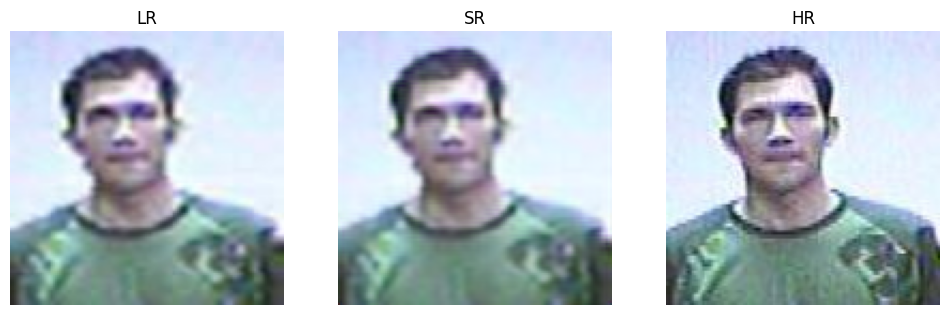

In [39]:
import torch
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# ---- Load model ----
model = model
ckpt = torch.load("./checkpoints/swinir_face_sr_latest.pth", map_location=device)
model.load_state_dict(ckpt["model_state"])
model.to(device)
model.eval()

# ---- Pick sample ----
idx = 120
lr_img, hr_img = val_dataset[idx]

lr_batch = lr_img.unsqueeze(0).to(device)
hr_batch = hr_img.unsqueeze(0).to(device)

with torch.no_grad():
    sr_batch = model(lr_batch)

# ---- Metrics ----
l1_lr  = l1_criterion(lr_batch, hr_batch).item()
vgg_lr = vgg_loss_fn(lr_batch, hr_batch).item()
id_lr  = id_loss_fn(lr_batch, hr_batch).item()

l1_sr  = l1_criterion(sr_batch, hr_batch).item()
vgg_sr = vgg_loss_fn(sr_batch, hr_batch).item()
id_sr  = id_loss_fn(sr_batch, hr_batch).item()

# ---- Print results ----
print("==== Single sample metrics ====")
print(f"L1   baseline: {l1_lr:.4f}  | SR: {l1_sr:.4f}  | Δ = {l1_lr - l1_sr:+.4f}")
print(f"VGG  baseline: {vgg_lr:.4f} | SR: {vgg_sr:.4f} | Δ = {vgg_lr - vgg_sr:+.4f}")
print(f"ID   baseline: {id_lr:.4f}  | SR: {id_sr:.4f} | Δ = {id_lr - id_sr:+.4f}")

# ---- Visualize ----
lr_vis = lr_batch[0].cpu().permute(1,2,0).numpy()
sr_vis = sr_batch[0].cpu().permute(1,2,0).numpy()
hr_vis = hr_batch[0].cpu().permute(1,2,0).numpy()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(lr_vis); plt.title("LR"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(sr_vis); plt.title("SR"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(hr_vis); plt.title("HR"); plt.axis("off")
plt.show()


In [34]:
model.eval()

n_samples = 0
sum_l1_lr  = sum_l1_sr  = 0.0
sum_vgg_lr = sum_vgg_sr = 0.0
sum_id_lr  = sum_id_sr  = 0.0

with torch.no_grad():
    for lr_batch, hr_batch in val_loader:
        lr_batch = lr_batch.to(device)
        hr_batch = hr_batch.to(device)

        sr_batch = model(lr_batch)

        # batch sizes
        b = lr_batch.size(0)
        n_samples += b

        # --- baseline: LR vs HR ---
        l1_lr_batch  = l1_criterion(lr_batch, hr_batch).item()
        vgg_lr_batch = vgg_loss_fn(lr_batch, hr_batch).item()
        id_lr_batch  = id_loss_fn(lr_batch, hr_batch).item()

        # --- after SR: SR vs HR ---
        l1_sr_batch  = l1_criterion(sr_batch, hr_batch).item()
        vgg_sr_batch = vgg_loss_fn(sr_batch, hr_batch).item()
        id_sr_batch  = id_loss_fn(sr_batch, hr_batch).item()

        # accumulate *weighted* by batch size
        sum_l1_lr  += l1_lr_batch  * b
        sum_l1_sr  += l1_sr_batch  * b
        sum_vgg_lr += vgg_lr_batch * b
        sum_vgg_sr += vgg_sr_batch * b
        sum_id_lr  += id_lr_batch  * b
        sum_id_sr  += id_sr_batch  * b

        # limit number of batches to keep it quick (optional)
        if n_samples >= 50:   # evaluate on ~50 samples
            break

# averages
avg_l1_lr  = sum_l1_lr  / n_samples
avg_l1_sr  = sum_l1_sr  / n_samples
avg_vgg_lr = sum_vgg_lr / n_samples
avg_vgg_sr = sum_vgg_sr / n_samples
avg_id_lr  = sum_id_lr  / n_samples
avg_id_sr  = sum_id_sr  / n_samples

print(f"\n=== Validation (approx {n_samples} samples) ===")
print(f"L1   baseline: {avg_l1_lr:.4f}  | after SR: {avg_l1_sr:.4f}  | Δ = {avg_l1_lr - avg_l1_sr:+.4f}")
print(f"VGG  baseline: {avg_vgg_lr:.4f} | after SR: {avg_vgg_sr:.4f} | Δ = {avg_vgg_lr - avg_vgg_sr:+.4f}")
print(f"ID   baseline: {avg_id_lr:.4f}  | after SR: {avg_id_sr:.4f}  | Δ = {avg_id_lr - avg_id_sr:+.4f}")

cos_lr = 1.0 - avg_id_lr
cos_sr = 1.0 - avg_id_sr
print(f"ID cosine sim baseline: {cos_lr:.4f} | after SR: {cos_sr:.4f} | Δ = {cos_sr - cos_lr:+.4f}")

def pct_improve(before, after):
    return 100.0 * (before - after) / max(before, 1e-8)

print(f"L1   % improvement: {pct_improve(avg_l1_lr, avg_l1_sr):+.2f}%")
print(f"VGG  % improvement: {pct_improve(avg_vgg_lr, avg_vgg_sr):+.2f}%")
print(f"ID   % improvement (loss): {pct_improve(avg_id_lr, avg_id_sr):+.2f}%")
print(f"ID cosine similarity % improvement: {100.0 * (cos_sr - cos_lr) / max(abs(cos_lr), 1e-8):+.2f}%")




=== Validation (approx 56 samples) ===
L1   baseline: 0.0308  | after SR: 0.0304  | Δ = +0.0004
VGG  baseline: 0.9049 | after SR: 0.8403 | Δ = +0.0646
ID   baseline: 0.3435  | after SR: 0.3696  | Δ = -0.0261
ID cosine sim baseline: 0.6565 | after SR: 0.6304 | Δ = -0.0261
L1   % improvement: +1.16%
VGG  % improvement: +7.13%
ID   % improvement (loss): -7.59%
ID cosine similarity % improvement: -3.97%


## CLEAR MEMORY 

In [40]:
import gc, torch

del model
del optimizer
del train_loader
del vgg_loss_fn
del id_loss_fn
# del anything else big: validation loader, checkpoints, etc.

gc.collect()

# If you’re using MPS:
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

In [1]:
from tqdm.notebook import tqdm
import time

for i in tqdm(range(100), desc="Test bar"):
    time.sleep(0.05)

Test bar:   0%|          | 0/100 [00:00<?, ?it/s]